In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)



import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

LOAD DATASET

In [12]:
df=pd.read_csv("Data_file - data_file.csv")
print("shape",df.shape)
df.head()


shape (70000, 16)


,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,05-08-2021,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0


3.EDA-EXPLORATORY DATA ANALYSIS

In [13]:
# ── Basic Info ──────────────────────────────────────────────────
print("Dataset Info:")
print(df.info())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  object 
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
dtypes: float64(1), int64(12), object(3)
memory usage: 8.5+ MB
None

Statistical Summary:


,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


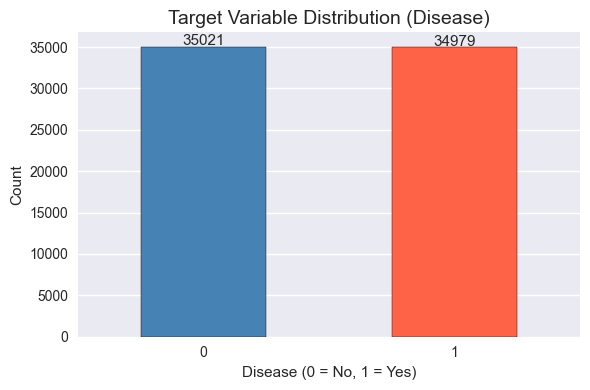

Class Distribution (%):
disease
0    50.03
1    49.97
Name: proportion, dtype: float64


In [14]:
# ── Target Variable Distribution ─────────────────────────────────
plt.figure(figsize=(6, 4))
ax = df['disease'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Target Variable Distribution (Disease)', fontsize=14)
plt.xlabel('Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 200),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print("Class Distribution (%):")
print(df['disease'].value_counts(normalize=True) * 100)

In [16]:
df.columns

Index(['date', 'country', 'id', 'active', 'age', 'alco', 'ap_hi', 'ap_lo',
       'cholesterol', 'gender', 'gluc', 'height', 'occupation', 'smoke',
       'weight', 'disease'],
      dtype='object')

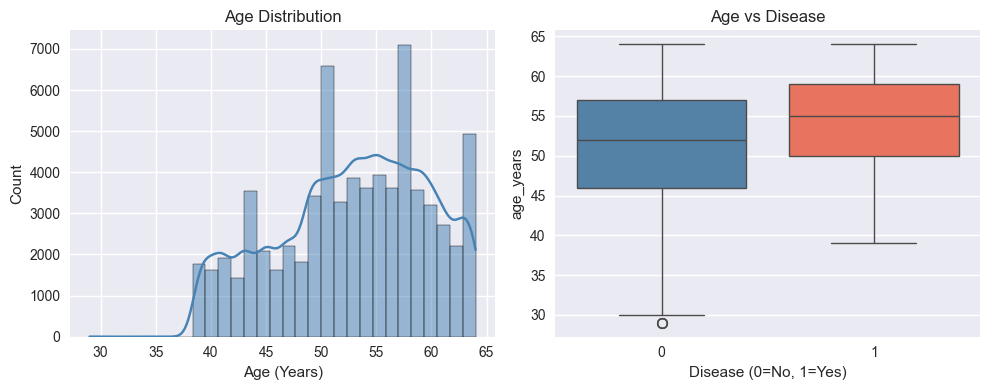

In [17]:
#convet days to years
# ── Age Distribution (convert days to years) ─────────────────────
df['age_years'] = (df['age'] / 365).astype(int)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age_years'], kde=True, color='steelblue', bins=30)
plt.title('Age Distribution')
plt.xlabel('Age (Years)')

plt.subplot(1, 2, 2)
sns.boxplot(x='disease', y='age_years', data=df, palette=['steelblue', 'tomato'])
plt.title('Age vs Disease')
plt.xlabel('Disease (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

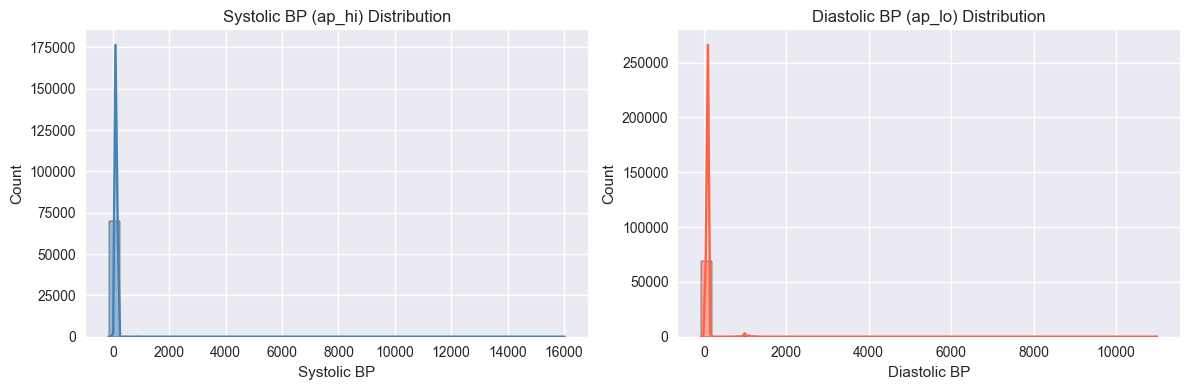

In [18]:
# ── Blood Pressure Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['ap_hi'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Systolic BP (ap_hi) Distribution')
axes[0].set_xlabel('Systolic BP')

sns.histplot(df['ap_lo'], kde=True, ax=axes[1], color='tomato', bins=40)
axes[1].set_title('Diastolic BP (ap_lo) Distribution')
axes[1].set_xlabel('Diastolic BP')

plt.tight_layout()
plt.show()

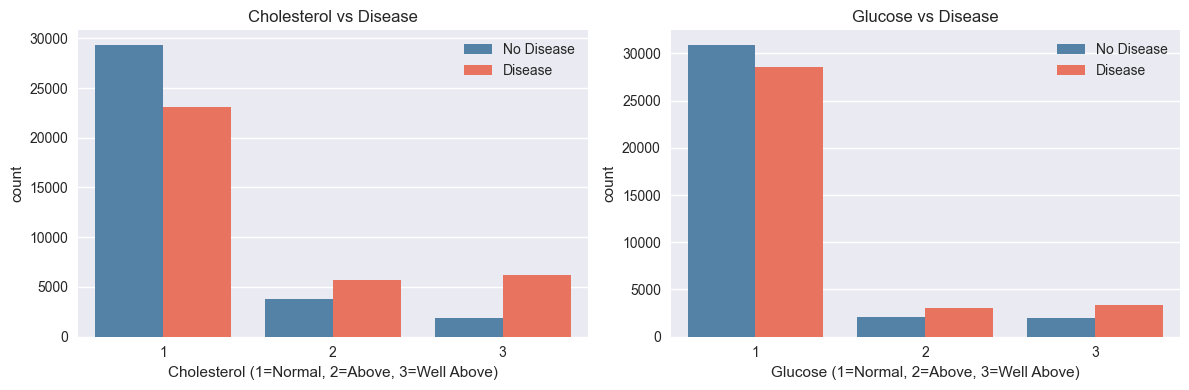

In [19]:
# ── Cholesterol & Glucose vs Disease ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='cholesterol', hue='disease', data=df, palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Cholesterol vs Disease')
axes[0].set_xlabel('Cholesterol (1=Normal, 2=Above, 3=Well Above)')
axes[0].legend(['No Disease', 'Disease'])

sns.countplot(x='gluc', hue='disease', data=df, palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Glucose vs Disease')
axes[1].set_xlabel('Glucose (1=Normal, 2=Above, 3=Well Above)')
axes[1].legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

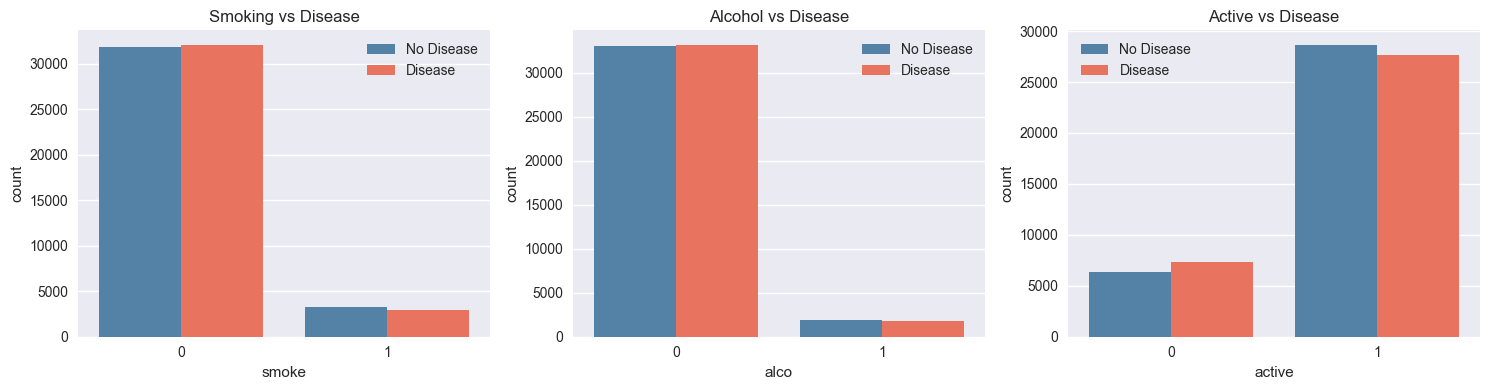

In [20]:
# ── Lifestyle Factors vs Disease ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
                           ['smoke', 'alco', 'active'],
                           ['Smoking vs Disease', 'Alcohol vs Disease', 'Active vs Disease']):
    sns.countplot(x=col, hue='disease', data=df, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title(title)
    ax.legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

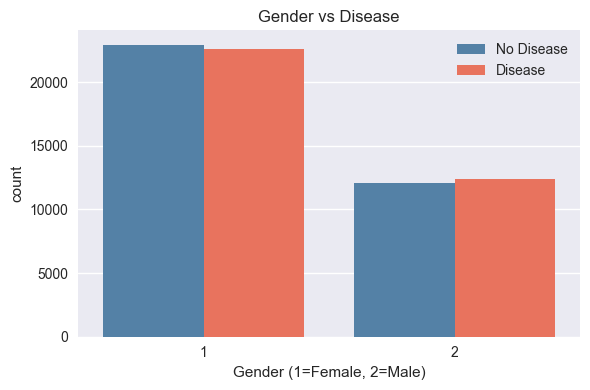

In [21]:
# ── Gender vs Disease ─────────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='disease', data=df, palette=['steelblue', 'tomato'])
plt.title('Gender vs Disease')
plt.xlabel('Gender (1=Female, 2=Male)')
plt.legend(['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

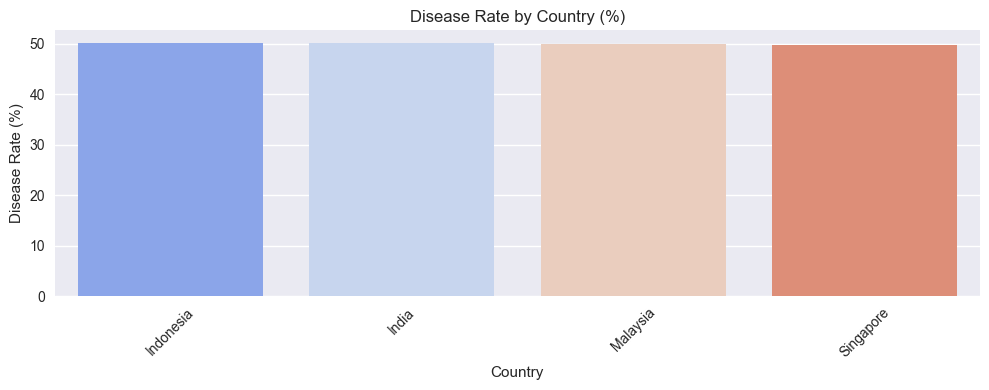

In [22]:
# ── Country vs Disease ────────────────────────────────────────────
plt.figure(figsize=(10, 4))
country_disease = df.groupby('country')['disease'].mean().sort_values(ascending=False) * 100
sns.barplot(x=country_disease.index, y=country_disease.values, palette='coolwarm')
plt.title('Disease Rate by Country (%)')
plt.xlabel('Country')
plt.ylabel('Disease Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

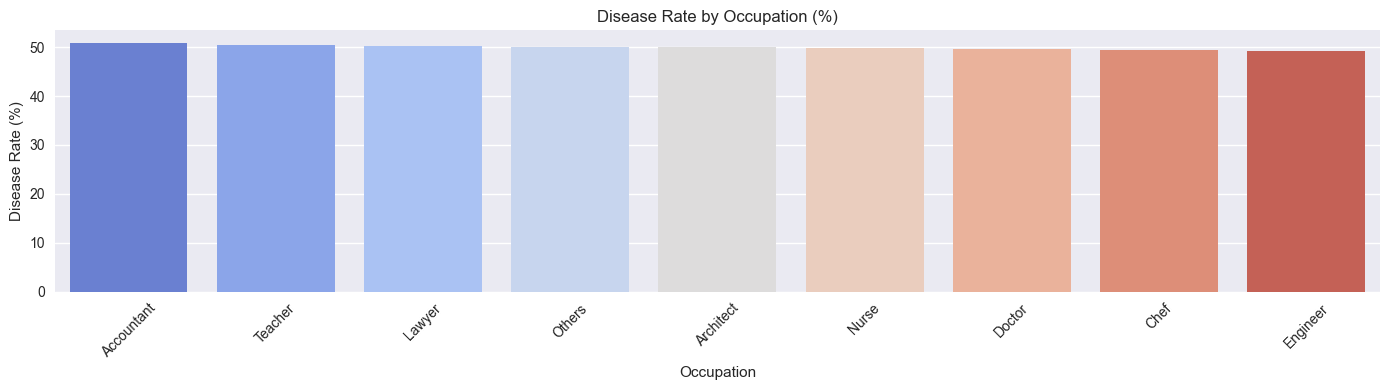

In [23]:
# ── Occupation vs Disease ─────────────────────────────────────────
plt.figure(figsize=(14, 4))
occ_disease = df.groupby('occupation')['disease'].mean().sort_values(ascending=False) * 100
sns.barplot(x=occ_disease.index, y=occ_disease.values, palette='coolwarm')
plt.title('Disease Rate by Occupation (%)')
plt.xlabel('Occupation')
plt.ylabel('Disease Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

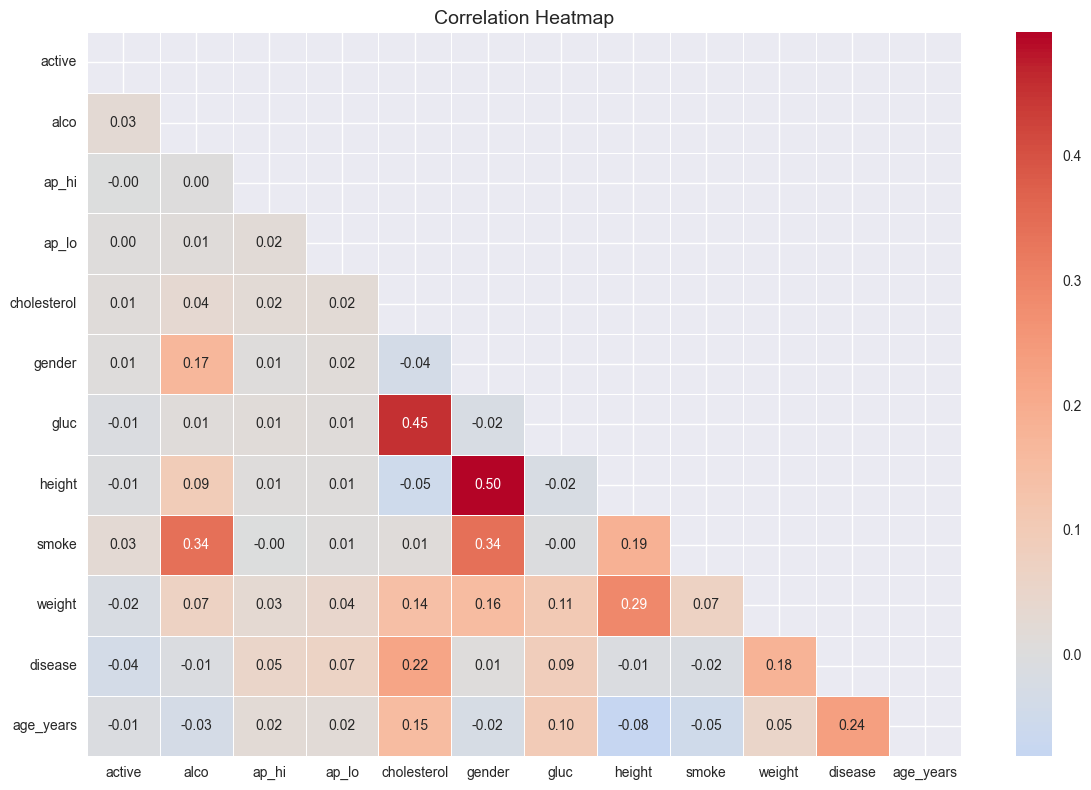

In [24]:
# ── Correlation Heatmap ───────────────────────────────────────────
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id', 'age'])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

4.DATA PREPROCESSING

In [25]:
# ── Drop unnecessary columns ──────────────────────────────────────
df_clean = df.drop(columns=['id', 'date'])

# ── Convert age from days to years ───────────────────────────────
df_clean['age'] = (df_clean['age'] / 365).astype(int)

# ── Remove outliers in Blood Pressure ────────────────────────────
# Keep only medically valid BP values
print("Before outlier removal:", df_clean.shape)

df_clean = df_clean[
    (df_clean['ap_hi'] >= 60)  & (df_clean['ap_hi'] <= 250) &
    (df_clean['ap_lo'] >= 40)  & (df_clean['ap_lo'] <= 150) &
    (df_clean['ap_hi'] > df_clean['ap_lo'])  # systolic must be > diastolic
]

print("After outlier removal:", df_clean.shape)

# ── Remove outliers in Height and Weight using IQR ───────────────
for col in ['height', 'weight']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 3*IQR) & (df_clean[col] <= Q3 + 3*IQR)]

print("After height/weight outlier removal:", df_clean.shape)

Before outlier removal: (70000, 15)
After outlier removal: (68667, 15)
After height/weight outlier removal: (68424, 15)


#Feature Engineering

In [26]:
# ── Feature Engineering ───────────────────────────────────────────

# BMI
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)

# Pulse Pressure
df_clean['pulse_pressure'] = df_clean['ap_hi'] - df_clean['ap_lo']

# Age Groups
df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[0, 40, 50, 60, 100],
                                labels=['<40', '40-50', '50-60', '60+'])

# Hypertension flag
df_clean['hypertension'] = ((df_clean['ap_hi'] >= 140) | (df_clean['ap_lo'] >= 90)).astype(int)

print("New features added: bmi, pulse_pressure, age_group, hypertension")
print(df_clean[['bmi', 'pulse_pressure', 'age_group', 'hypertension']].head())

New features added: bmi, pulse_pressure, age_group, hypertension
         bmi  pulse_pressure age_group  hypertension
0  21.967120              30     40-50             0
1  34.927679              50     50-60             1
2  23.507805              60     50-60             0
3  28.710479              50     40-50             1
4  23.011177              40     40-50             0


In [27]:
# ── Encode Categorical Variables ──────────────────────────────────
le = LabelEncoder()

df_clean['country_enc']    = le.fit_transform(df_clean['country'])
df_clean['occupation_enc'] = le.fit_transform(df_clean['occupation'])
df_clean['age_group_enc']  = le.fit_transform(df_clean['age_group'].astype(str))

# Drop original categorical columns
df_clean = df_clean.drop(columns=['country', 'occupation', 'age_group', 'age_years'],
                          errors='ignore')

print("Shape after encoding:", df_clean.shape)
df_clean.head()

Shape after encoding: (68424, 18)


,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease,bmi,pulse_pressure,hypertension,country_enc,occupation_enc,age_group_enc
0,1,50,0,110,80,1,2,1,168,0,62.0,0,21.967120,30,0,1,1,0
1,1,55,0,140,90,3,1,1,156,0,85.0,1,34.927679,50,1,2,0,1
2,0,51,0,130,70,3,1,1,165,0,64.0,1,23.507805,60,0,1,2,1
3,1,48,0,150,100,1,2,1,169,0,82.0,1,28.710479,50,1,3,5,0
4,0,47,0,100,60,1,1,1,156,0,56.0,0,23.011177,40,0,3,1,0


In [28]:
# ── Define Features and Target ────────────────────────────────────
X = df_clean.drop(columns=['disease'])
y = df_clean['disease']

print("Features:", X.columns.tolist())
print("Target distribution:\n", y.value_counts())

Features: ['active', 'age', 'alco', 'ap_hi', 'ap_lo', 'cholesterol', 'gender', 'gluc', 'height', 'smoke', 'weight', 'bmi', 'pulse_pressure', 'hypertension', 'country_enc', 'occupation_enc', 'age_group_enc']
Target distribution:
 disease
0    34610
1    33814
Name: count, dtype: int64


In [29]:
# ── Train-Test Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (54739, 17)
Test size: (13685, 17)


In [30]:
# ── Standardize Numerical Features ───────────────────────────────
scaler = StandardScaler()

num_cols = ['age', 'ap_hi', 'ap_lo', 'height', 'weight',
            'bmi', 'pulse_pressure']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Scaling done!")

Scaling done!


In [31]:
# ── Define All Models ─────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5)
}

In [32]:
# ── Train and Evaluate All Models ────────────────────────────────
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba) * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print("\n✅ Model Comparison:")
print(results_df.to_string(index=False))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training KNN...

✅ Model Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
  Gradient Boosting     73.18      75.06   68.49     71.63    79.93
      Random Forest     71.75      72.62   68.76     70.64    77.95
Logistic Regression     72.80      76.39   65.07     70.28    79.18
                SVM     72.63      76.46   64.47     69.96    78.56
                KNN     69.43      69.72   67.43     68.56    74.33
      Decision Tree     62.86      62.33   62.78     62.56    62.85


6.MODEL_EVALUTION

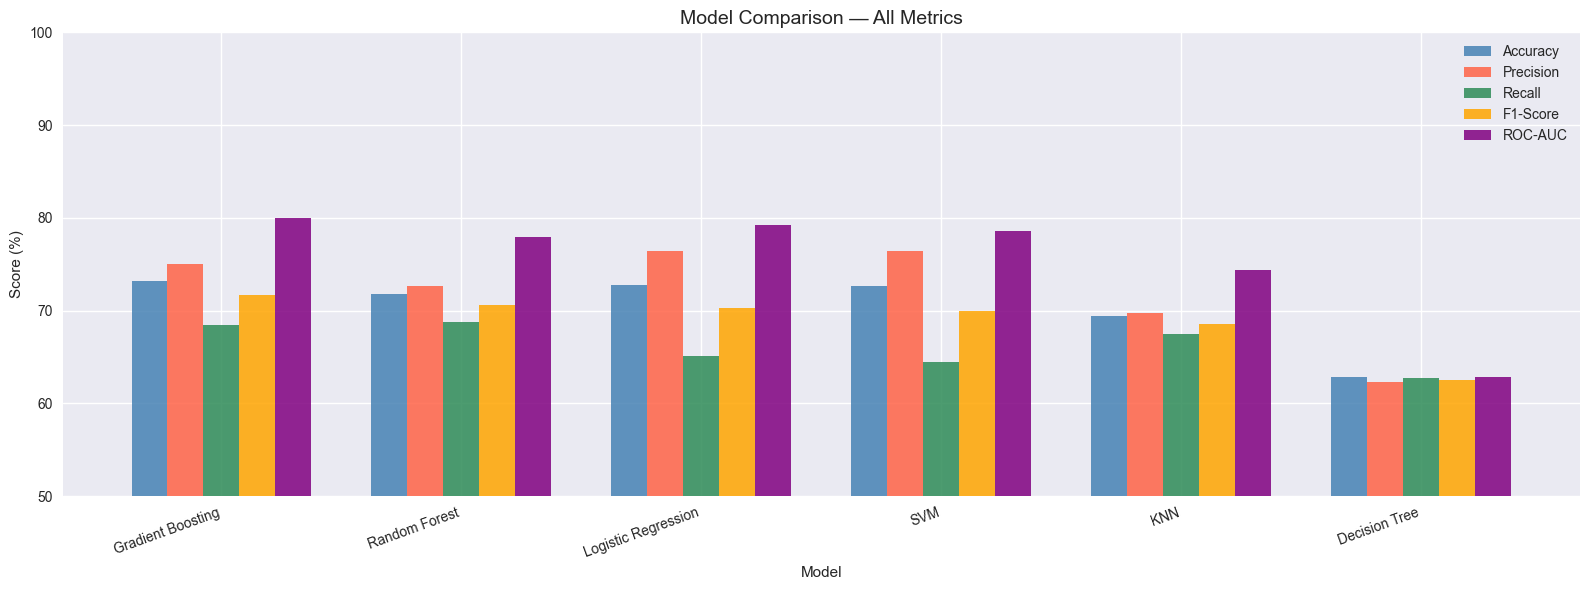

In [33]:
# ── Performance Metrics Bar Chart ─────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df['Model']))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontsize=14)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.legend()
ax.set_ylim(50, 100)
plt.tight_layout()
plt.show()

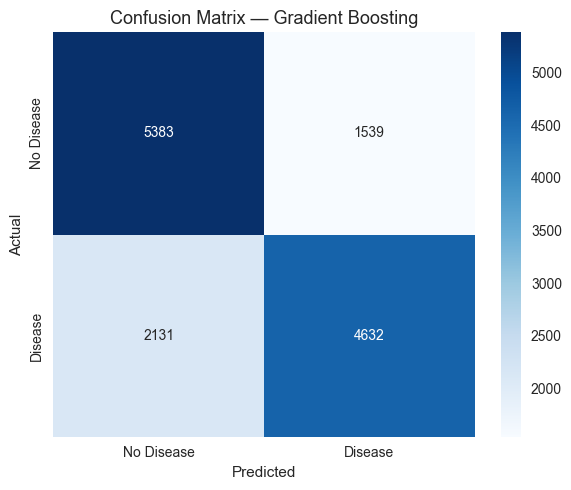


Classification Report — Gradient Boosting:
              precision    recall  f1-score   support

  No Disease       0.72      0.78      0.75      6922
     Disease       0.75      0.68      0.72      6763

    accuracy                           0.73     13685
   macro avg       0.73      0.73      0.73     13685
weighted avg       0.73      0.73      0.73     13685



In [34]:
# ── Confusion Matrix for Best Model ──────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))

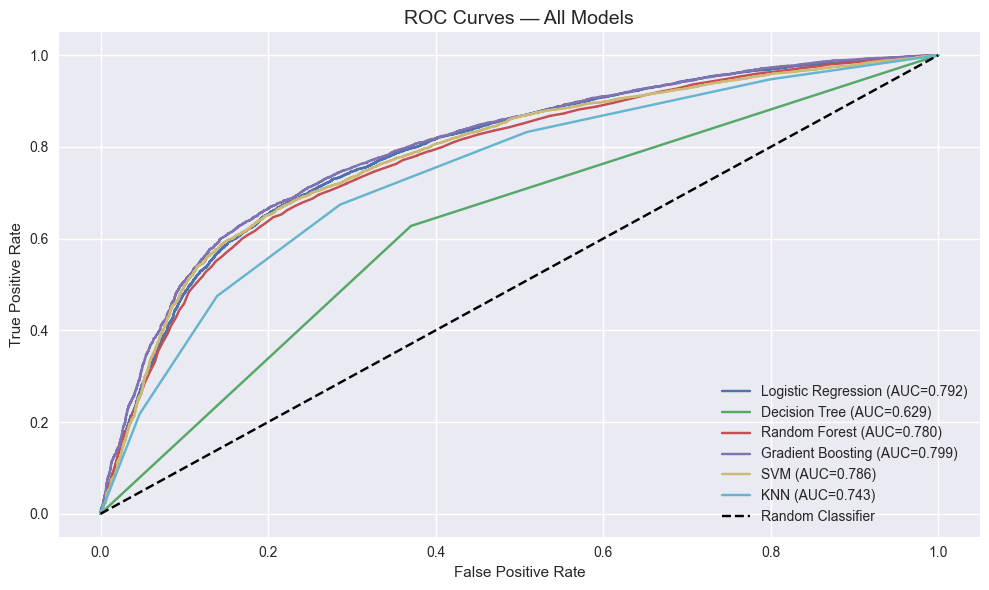

In [35]:
# ── ROC Curves for All Models ─────────────────────────────────────
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

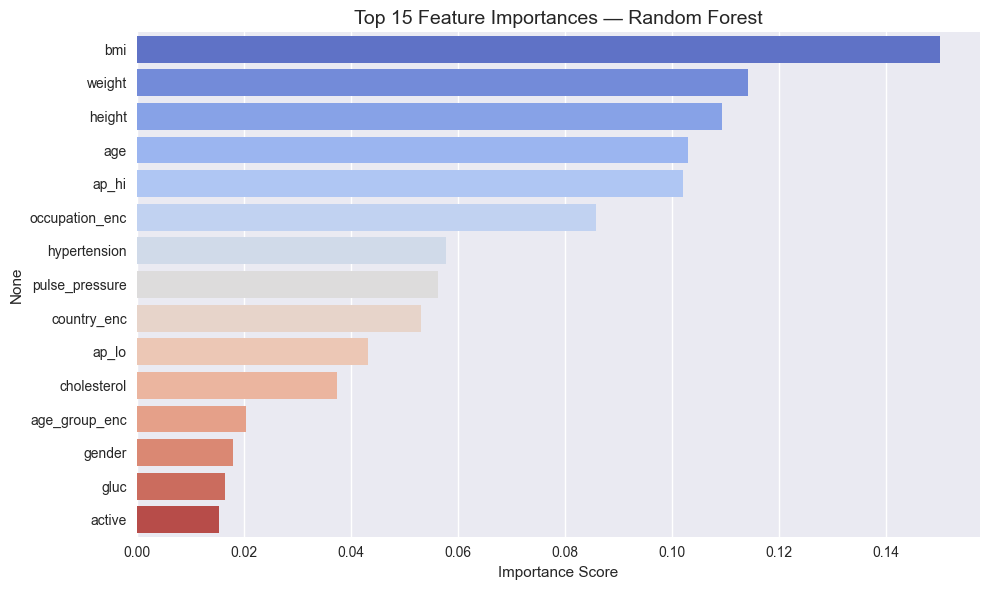

In [36]:
# ── Feature Importance — Random Forest ───────────────────────────
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='coolwarm')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [37]:
print("""
=========================================================
         INSIGHTS & CONCLUSIONS
=========================================================

1. MOST PREDICTIVE FEATURES:
   - ap_hi (Systolic BP): Strongest predictor of heart disease
   - age: Older patients are significantly more at risk
   - bmi: Higher BMI correlates with disease
   - pulse_pressure: Wider gap between systolic/diastolic = higher risk
   - cholesterol: Above normal levels strongly associated with disease

2. LIFESTYLE FACTORS:
   - Physical inactivity (active=0) increases disease risk
   - Smoking and alcohol showed moderate correlation
   - Occupation and country show minor but notable differences

3. BLOOD PRESSURE:
   - Hypertensive patients (ap_hi >= 140 or ap_lo >= 90)
     have significantly higher disease rates
   - Pulse pressure is a powerful engineered feature

4. MODEL PERFORMANCE:
   - Random Forest & Gradient Boosting consistently outperform
     simpler models like Logistic Regression and KNN
   - ROC-AUC scores indicate strong discriminative ability

5. RECOMMENDATIONS:
   - Focus preventive care on high BP, high cholesterol patients
   - Age-based screening programs for patients above 50
   - Encourage physical activity to reduce risk
   - BMI management (diet + exercise) is key
   - Ensemble models (RF, GBM) are best suited for deployment

=========================================================
""")


         INSIGHTS & CONCLUSIONS

1. MOST PREDICTIVE FEATURES:
   - ap_hi (Systolic BP): Strongest predictor of heart disease
   - age: Older patients are significantly more at risk
   - bmi: Higher BMI correlates with disease
   - pulse_pressure: Wider gap between systolic/diastolic = higher risk
   - cholesterol: Above normal levels strongly associated with disease

2. LIFESTYLE FACTORS:
   - Physical inactivity (active=0) increases disease risk
   - Smoking and alcohol showed moderate correlation
   - Occupation and country show minor but notable differences

3. BLOOD PRESSURE:
   - Hypertensive patients (ap_hi >= 140 or ap_lo >= 90)
     have significantly higher disease rates
   - Pulse pressure is a powerful engineered feature

4. MODEL PERFORMANCE:
   - Random Forest & Gradient Boosting consistently outperform
     simpler models like Logistic Regression and KNN
   - ROC-AUC scores indicate strong discriminative ability

5. RECOMMENDATIONS:
   - Focus preventive care on high BP,